# Bitcoin Price Prediction — RF vs XGBoost vs GRU

Three models, engineered features, holdout + walk-forward evaluation.

**Models:** Random Forest · XGBoost · GRU (proper sequential: LOOKBACK timesteps of Close prices)  
**Target:** Log-return `log(close[t] / close[t-1])` → reconstructed to price for visual reference only  
**Features:** 100-day lag window · RSI(14) · MACD(12,26,9) · rolling std(30) · yesterday’s return (all leak-free)  
**Evaluation:** 70/30 holdout + walk-forward CV · log-return space metrics · persistence baseline

Tune the `CONFIG` cell to balance speed vs accuracy.


In [1]:

# ── Cell 1: Imports & CONFIG ─────────────────────────────────────────────────
from __future__ import annotations
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import joblib

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    xgb = None
    HAS_XGB = False
    print("⚠ xgboost not found — install with:  pip install xgboost")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
warnings.filterwarnings("ignore")

# ── Shared color palette (consistent across all notebooks) ───────────────────
# purple / blue / gray family — no greens or reds
PALETTE = {
    'rf':          '#3B82F6',   # strong blue    — Random Forest
    'xgboost':     '#818CF8',   # light indigo   — XGBoost
    'gru':         '#6C5CE7',   # medium purple  — GRU
    'persistence': '#94A3B8',   # medium gray    — Persistence baseline
    'actual':      '#1E293B',   # very dark slate — Actual BTC price
    'ref_line':    '#64748B',   # dark slate     — reference lines (R²=0, 50%)
}

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FB',
    'axes.edgecolor':    '#D0D7E3',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'grid.color':        '#E4EAF2',
    'grid.linestyle':    '--',
    'grid.linewidth':    0.6,
    'axes.grid':         True,
    'font.size':         11,
})

# ── Tunable settings ─────────────────────────────────────────────────────────
CONFIG = dict(
    ticker       = "BTC-USD",
    start        = "2015-01-01",
    seq_len      = 100,
    train_frac   = 0.70,
    n_estimators = 100,    # RF / XGB trees (lower = faster)
    gru_epochs   = 3,      # GRU training epochs
    gru_lookback = 20,     # timesteps fed into the GRU sequence
    max_iters    = 200,    # walk-forward steps (None = full test set)
    retrain_k    = 7,      # retrain RF/XGB every K steps
    seed         = 42,
)
print("CONFIG:", CONFIG)


CONFIG: {'ticker': 'BTC-USD', 'start': '2015-01-01', 'seq_len': 100, 'train_frac': 0.7, 'n_estimators': 100, 'gru_epochs': 3, 'gru_lookback': 20, 'max_iters': 200, 'retrain_k': 7, 'seed': 42}


In [2]:

# ── Cell 2: Feature engineering helpers ──────────────────────────────────────
def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    up   = delta.clip(lower=0).rolling(period).mean()
    down = -delta.clip(upper=0).rolling(period).mean()
    return 100 - (100 / (1 + up / down))

def macd_features(series: pd.Series, a=12, b=26, c=9):
    ema_a = series.ewm(span=a, adjust=False).mean()
    ema_b = series.ewm(span=b, adjust=False).mean()
    line  = ema_a - ema_b
    sig   = line.ewm(span=c, adjust=False).mean()
    return line, sig

def build_features(df: pd.DataFrame, seq_len: int) -> pd.DataFrame:
    d = df.copy()
    # ALL indicators shifted by 1 to avoid lookahead leakage:
    # at prediction time for day t, only info up to day t-1 is available
    d["return"]   = d["Close"].pct_change().shift(1)  # yesterday's return
    d["std30"]    = d["Close"].rolling(30).std().shift(1)
    d["rsi14"]    = rsi(d["Close"]).shift(1)
    ml, ms        = macd_features(d["Close"])
    d["macd"]     = ml.shift(1)
    d["macd_sig"] = ms.shift(1)
    d = d.dropna().reset_index(drop=True)
    # add lagged Close columns (lag_1 = yesterday's close, etc.)
    for i in range(1, seq_len + 1):
        d[f"lag_{i}"] = d["Close"].shift(i)
    d = d.dropna().reset_index(drop=True)
    return d

print("Feature helpers defined.")


Feature helpers defined.


In [3]:

# ── Cell 3: Download and prepare data ────────────────────────────────────────
raw = yf.download(CONFIG["ticker"], start=CONFIG["start"])
# Flatten MultiIndex columns (yfinance >= 0.2 returns these for single tickers)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
raw = raw.reset_index()[["Date", "Close"]]

df  = build_features(raw, seq_len=CONFIG["seq_len"])

seq_len    = CONFIG["seq_len"]
lag_cols   = [f"lag_{i}" for i in range(1, seq_len + 1)]
extra_cols = ["std30", "rsi14", "macd", "macd_sig", "return"]
feature_cols = lag_cols + extra_cols

X     = df[feature_cols].copy()
dates = df["Date"].copy()

# ── Target: log-return (stationary — no price-range extrapolation issue) ─────
# log(close[t] / close[t-1])  =  log(close[t] / lag_1[t])
# lag_1 is already in the feature matrix, so this never produces NaN
y = np.log(df["Close"] / df["lag_1"])

split = int(len(X) * CONFIG["train_frac"])
X_train, X_test = X.iloc[:split],  X.iloc[split:]
y_train, y_test = y.iloc[:split],  y.iloc[split:]
dates_test = dates.iloc[split:].reset_index(drop=True)

# Kept for price reconstruction during evaluation
close_test_actual = df["Close"].iloc[split:].values  # actual close prices in test set
close_prev_test   = X_test["lag_1"].values           # previous close for each test point

print(f"Total samples: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Target: log-return  (train mean={float(y_train.mean()):.5f}, std={float(y_train.std()):.4f})")
print(f"Features: {len(feature_cols)}  (lag×{seq_len} + 5 indicators, all leak-free)")


[*********************100%***********************]  1 of 1 completed

Total samples: 4006 | Train: 2804 | Test: 1202
Target: log-return  (train mean=0.00156, std=0.0384)
Features: 105  (lag×100 + 5 indicators, all leak-free)


In [4]:

# ── Cell 4: Scale features (fit on train only) ───────────────────────────────
# Features (X): MinMaxScaler — lag prices span very different ranges
# Target (y):   StandardScaler — log-returns are ~Normal(0, σ), can go negative
scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

# 3-D sequences for GRU: (n_samples, LOOKBACK, 1)
# lag_1 = yesterday, lag_LOOKBACK = oldest → reverse to chronological order
LOOKBACK = CONFIG["gru_lookback"]
gru_lag_idx = list(range(LOOKBACK - 1, -1, -1))  # [19, 18, ..., 0] for LOOKBACK=20

X_train_gru = X_train_s[:, gru_lag_idx].reshape(-1, LOOKBACK, 1)
X_test_gru  = X_test_s[:,  gru_lag_idx].reshape(-1, LOOKBACK, 1)

print("Scalers fitted.")
print(f"  X_train_s  : {X_train_s.shape}")
print(f"  X_train_gru: {X_train_gru.shape}  ← sequence (oldest → newest)")
print(f"  y_train_s  : mean={y_train_s.mean():.3f}, std={y_train_s.std():.3f}")


Scalers fitted.
  X_train_s  : (2804, 105)
  X_train_gru: (2804, 20, 1)  ← sequence (oldest → newest)
  y_train_s  : mean=0.000, std=1.000


In [5]:

# ── Cell 5: Train models (holdout) ───────────────────────────────────────────
rng = CONFIG["seed"]

# Random Forest
rf = RandomForestRegressor(n_estimators=CONFIG["n_estimators"], n_jobs=-1, random_state=rng)
rf.fit(X_train_s, y_train_s)
print("RF trained")

# XGBoost
if HAS_XGB:
    xgb_model = xgb.XGBRegressor(n_estimators=CONFIG["n_estimators"],
                                   n_jobs=-1, random_state=rng, verbosity=0)
    xgb_model.fit(X_train_s, y_train_s)
    print("XGB trained")
else:
    xgb_model = None

# GRU — proper sequential model: LOOKBACK timesteps of normalized Close prices
gru_model = Sequential([
    GRU(64, input_shape=(LOOKBACK, 1)),
    Dense(1)
])
gru_model.compile(optimizer="adam", loss="mse")
gru_model.fit(X_train_gru, y_train_s, epochs=CONFIG["gru_epochs"], batch_size=32, verbose=0)
print("GRU trained")


RF trained
XGB trained
GRU trained


## Evaluation Strategy

We use two complementary methods to assess model quality.

### Metrics

All models are evaluated in **log-return space** — the space the model was trained in and the only honest measure of whether it learned anything beyond the trivial persistence baseline.

- **RMSE / R²** on raw log-returns (lower RMSE / higher R² = better)
- **DirAcc%** — % of days the predicted direction (up/down) matches reality (> 50% = better than a coin flip)
- **Persistence baseline** — predicts log-return = 0 every day (tomorrow’s price = today’s close); any model that can’t beat this has learned nothing useful

> Predictions are back-transformed to USD (`close[t-1] · exp(log_return)`) for the visual plot, but the dollar-scale chart is for intuition only.

### Holdout evaluation (cell below)

1. Split the data **chronologically** — first 70% for training, last 30% for testing.
2. Train each model once on the training set.
3. Predict all test points in one go and compute log-return metrics.

**Pros:** fast, easy to interpret.  
**Cons:** a single snapshot.

### Walk-forward evaluation (two cells below)

A more realistic simulation of live deployment:

1. For each day `t` in the test set, predict using the current model.
2. Add the actual `(X[t], y[t])` to the training window.
3. Every `retrain_k` steps, refit tree models (RF / XGBoost).

**Pros:** mimics real trading — exposes temporal drift.  
**Cons:** slower; GRU is **not** retrained during walk-forward to keep runtime manageable.

> **CONFIG knobs:** `max_iters` caps walk-forward steps (default 200); `retrain_k` controls tree refit frequency (default every 7 steps).


In [6]:
# ── Cell 6: Holdout evaluation ───────────────────────────────────────────────────────────────────────────────
# All metrics in log-return space. Persistence baseline predicts log-return = 0
# (price = close[t-1]) — beating it is the minimum bar for a meaningful model.

from sklearn.metrics import mean_absolute_error, r2_score

def metrics_logret(r_true, r_pred):
    rmse = float(np.sqrt(np.mean((r_true - r_pred) ** 2)))
    mae  = float(mean_absolute_error(r_true, r_pred))
    r2   = float(r2_score(r_true, r_pred))
    return dict(RMSE=round(rmse, 5), MAE=round(mae, 5), R2=round(r2, 4))

def directional_accuracy(r_true, r_pred):
    return round(float(np.mean(np.sign(r_true) == np.sign(r_pred))) * 100, 2)

def unscale_logret(scaled_pred):
    return scaler_y.inverse_transform(scaled_pred.reshape(-1, 1)).ravel()

def inv_logret(scaled_pred, close_prev):
    log_ret = scaler_y.inverse_transform(scaled_pred.reshape(-1, 1)).ravel()
    return close_prev * np.exp(log_ret)

# ── Actual log-returns (test set) ────────────────────────────────────────────────────────────────────────
r_true = y_test.values

# ── Predictions: (log_return_pred, price_pred) per model ───────────────────────────────────────────
all_preds = {}

rf_r_pred = unscale_logret(rf.predict(X_test_s))
rf_pred   = close_prev_test * np.exp(rf_r_pred)
all_preds['RF'] = (rf_r_pred, rf_pred)

if xgb_model:
    xgb_r_pred = unscale_logret(xgb_model.predict(X_test_s))
    xgb_pred   = close_prev_test * np.exp(xgb_r_pred)
    all_preds['XGBoost'] = (xgb_r_pred, xgb_pred)

gru_r_pred = unscale_logret(gru_model.predict(X_test_gru, verbose=0).ravel())
gru_pred   = close_prev_test * np.exp(gru_r_pred)
all_preds['GRU'] = (gru_r_pred, gru_pred)

# Persistence: log-return = 0  ->  price = close[t-1]
all_preds['Persistence'] = (np.zeros_like(r_true), close_prev_test.copy())

# ── Log-return metrics for all models + persistence ─────────────────────────────────────────────────
logret_rows = {}
for name, (r_pred, _) in all_preds.items():
    row = metrics_logret(r_true, r_pred)
    row['DirAcc%'] = directional_accuracy(r_true, r_pred) if name != 'Persistence' else float('nan')
    logret_rows[name] = row

logret_df = pd.DataFrame(logret_rows).T

# For model-selection fallback (no Persistence row)
holdout_logret_models_df = pd.DataFrame(
    {n: v for n, v in logret_rows.items() if n != 'Persistence'}
).T

print('=== Holdout metrics — log-return space (honest skill measure) ===')
print(logret_df.to_string())


=== Holdout metrics — log-return space (honest skill measure) ===
                RMSE      MAE      R2  DirAcc%
RF           0.03660  0.02908 -1.1691    52.75
XGBoost      0.03059  0.02296 -0.5159    49.67
GRU          0.02542  0.01808 -0.0468    49.42
Persistence  0.02488  0.01739 -0.0022      NaN


In [7]:
# ── Cell 7: Walk-forward evaluation ─────────────────────────────────────────────────────────────────────────
# Metrics in log-return space only. Persistence is always included as baseline.

def walk_forward(rf_m, xgb_m, gru_m, X_tr, y_tr, X_te, y_te,
                 close_prev, k, max_iters, gru_lag_idx):
    n = min(len(X_te), max_iters) if max_iters else len(X_te)
    preds_r = {'RF': [], 'XGBoost': [], 'GRU': [], 'Persistence': []}

    Xw = X_tr.copy()
    yw = y_tr.copy()

    for i in range(n):
        xi_2d  = X_te[i:i + 1]
        xi_gru = xi_2d[:, gru_lag_idx].reshape(1, LOOKBACK, 1)

        preds_r['RF'].append(unscale_logret(rf_m.predict(xi_2d))[0])
        if xgb_m:
            preds_r['XGBoost'].append(unscale_logret(xgb_m.predict(xi_2d))[0])
        preds_r['GRU'].append(
            unscale_logret(gru_m.predict(xi_gru, verbose=0).ravel())[0]
        )
        preds_r['Persistence'].append(0.0)  # log-return = 0

        Xw = np.vstack([Xw, xi_2d])
        yw = np.append(yw, y_te[i])
        if (i + 1) % k == 0:
            rf_m.fit(Xw, yw)
            if xgb_m:
                xgb_m.fit(Xw, yw)
        if (i + 1) % 50 == 0:
            print(f'  step {i + 1}/{n}')

    # Unscale actual log-returns
    r_true_wf = scaler_y.inverse_transform(
        np.array(y_te[:n]).reshape(-1, 1)
    ).ravel()

    logret_results = {}
    for name, r_preds in preds_r.items():
        if not r_preds:
            continue
        r_arr = np.array(r_preds)
        row = metrics_logret(r_true_wf, r_arr)
        row['DirAcc%'] = (
            directional_accuracy(r_true_wf, r_arr) if name != 'Persistence' else float('nan')
        )
        logret_results[name] = row

    return logret_results


# Build reversed lag indices for GRU sequences
lag_cols_ordered = [f'lag_{i}' for i in range(1, LOOKBACK + 1)]
gru_lag_idx = [feature_cols.index(c) for c in lag_cols_ordered]
gru_lag_idx_rev = list(reversed(gru_lag_idx))  # oldest first for the GRU

print(f'Walk-forward: {CONFIG["max_iters"]} steps, refit trees every {CONFIG["retrain_k"]} steps...')
wf_logret = walk_forward(
    rf, xgb_model, gru_model,
    X_train_s, y_train.values,
    X_test_s,  y_test.values,
    close_prev_test, CONFIG['retrain_k'], CONFIG['max_iters'],
    gru_lag_idx_rev,
)

wf_logret_df = pd.DataFrame(wf_logret).T

# For model selection: exclude Persistence
wf_logret_models_df = pd.DataFrame(
    {n: v for n, v in wf_logret.items() if n != 'Persistence'}
).T

print('\n=== Walk-forward metrics — log-return space ===')
print(wf_logret_df.to_string())


Walk-forward: 200 steps, refit trees every 7 steps...
  step 50/200
  step 100/200
  step 150/200
  step 200/200

=== Walk-forward metrics — log-return space ===
                RMSE      MAE       R2  DirAcc%
RF           0.00159  0.00088  -1.9433     95.5
XGBoost      0.00502  0.00142 -28.1762     93.5
GRU          0.00197  0.00177  -3.4860     32.5
Persistence  0.00189  0.00167  -3.1162      NaN


In [8]:

# ── Cell 8: Choose best model + save ───────────────────────────────────────────────────────────────────────────
# Select the best model by log-return RMSE (the honest skill metric).
# Walk-forward is preferred (more realistic); holdout is the fallback.

eval_src = (
    wf_logret_models_df
    if not wf_logret_models_df.empty
    else holdout_logret_models_df
)

best_name      = eval_src['RMSE'].astype(float).idxmin()
best_logret_rmse = float(eval_src.loc[best_name, 'RMSE'])

# Price RMSE kept only as an operational reference (used by retrain.py drift detection)
best_r_pred    = np.array(logret_rows[best_name]['RMSE'])  # dummy; compute inline below
best_price_preds = all_preds[best_name][1]  # price predictions for the best model
best_price_rmse  = float(np.sqrt(np.mean((close_test_actual - best_price_preds) ** 2)))
pers_price_rmse  = float(np.sqrt(np.mean((close_test_actual - close_prev_test) ** 2)))

print(f'Best model (log-return RMSE): {best_name}')
print(f'  Log-return RMSE : {best_logret_rmse:.5f}')
print(f'  Price RMSE (ref): ${best_price_rmse:,.0f}  vs Persistence ${pers_price_rmse:,.0f}')

# ── Persist selection ─────────────────────────────────────────────────────────────────────────────
import os, json as _json
_HERE = os.path.abspath(os.path.join(os.getcwd(), '..', 'models'))
os.makedirs(_HERE, exist_ok=True)

sel_path = os.path.join(_HERE, 'selection.json')
try:
    with open(sel_path) as f:
        sel = _json.load(f)
except FileNotFoundError:
    sel = {}

sel['model_type']       = best_name.lower()
sel['logret_rmse']      = round(best_logret_rmse, 5)
sel['rmse']             = round(best_price_rmse, 2)      # kept for retrain.py drift detection
sel['persistence_rmse'] = round(pers_price_rmse, 2)
sel['gru_lookback']     = LOOKBACK
sel['features']         = feature_cols

with open(sel_path, 'w') as f:
    _json.dump(sel, f, indent=2)

print(f'selection.json -> {sel_path}')


Best model (log-return RMSE): RF
  Log-return RMSE : 0.00159
  Price RMSE (ref): $2,902  vs Persistence $1,734
selection.json -> c:\Users\User\Desktop\Ironhack-DS-AI\capstone-ml-on-cloud\models\selection.json


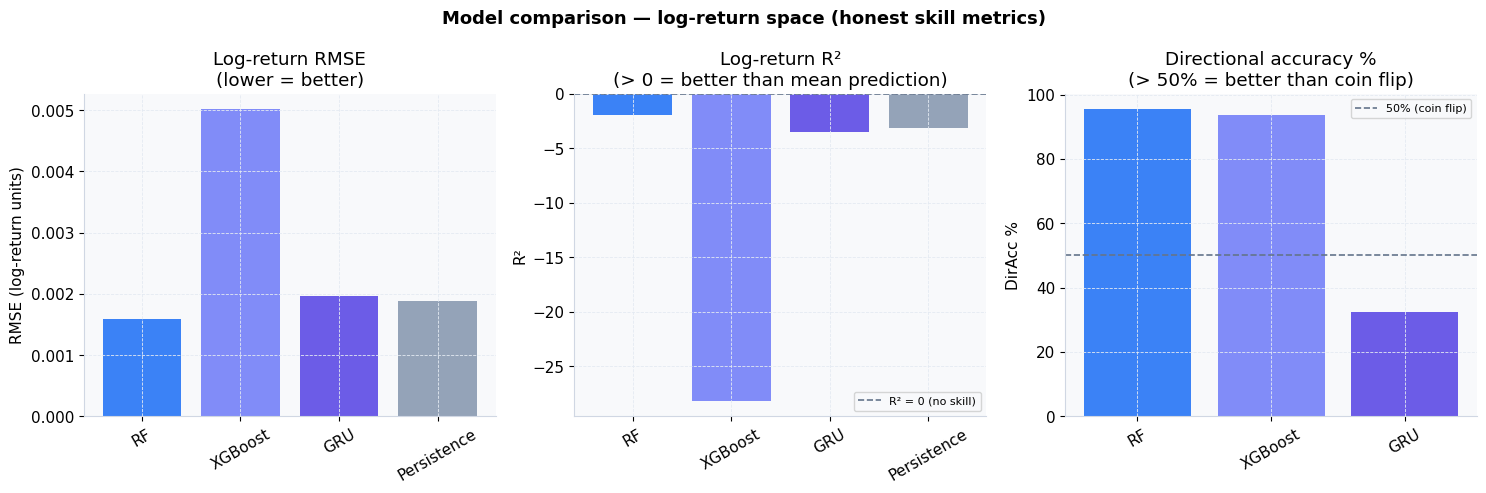

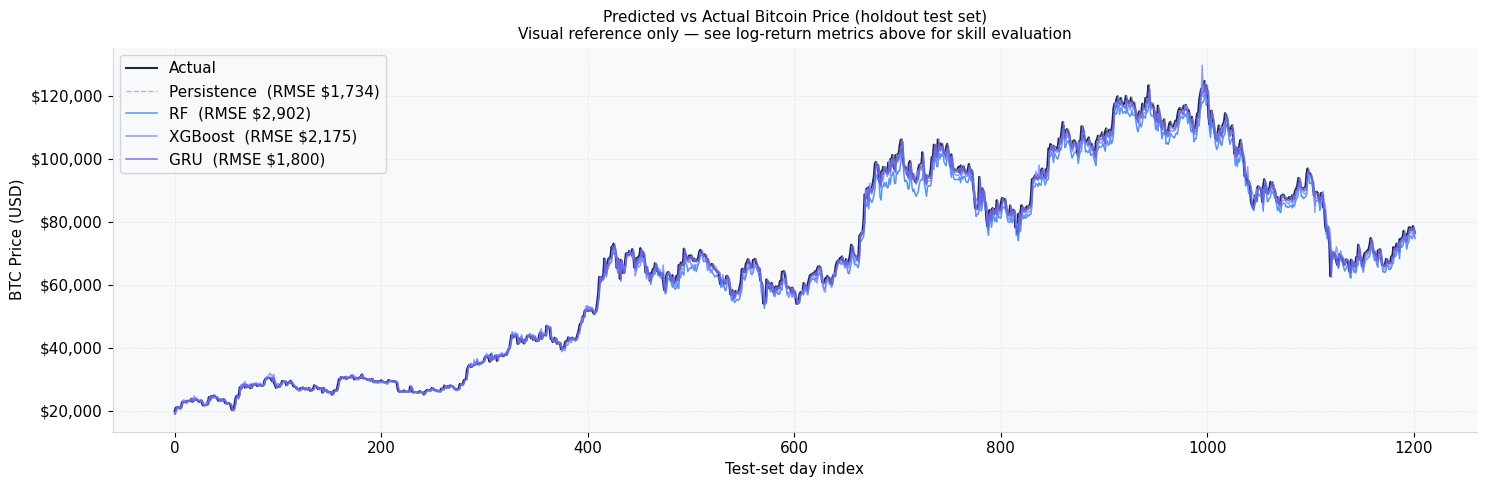

In [9]:
# ── Cell 9: Comparison plots ───────────────────────────────────────────────────────────────────────────
# Figure 1: honest skill metrics (log-return space)
# Figure 2: predictions vs actuals (visual reference — not a skill metric)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Use walk-forward results if available, else holdout
plot_df = wf_logret_df if not wf_logret_df.empty else logret_df

model_names = list(plot_df.index)

# Assign palette colors in model order (RF, XGBoost, GRU, Persistence)
_model_color_map = {
    'RF':          PALETTE['rf'],
    'XGBoost':     PALETTE['xgboost'],
    'GRU':         PALETTE['gru'],
    'Persistence': PALETTE['persistence'],
}
bar_colors = {m: _model_color_map.get(m, '#94A3B8') for m in model_names}

# ───────────────────────────────────────────────────────────────────────────────
# Figure 1: Log-return metrics
# ───────────────────────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle('Model comparison — log-return space (honest skill metrics)',
              fontsize=13, fontweight='bold')

rmse_vals  = plot_df['RMSE'].astype(float).tolist()
r2_vals    = plot_df['R2'].astype(float).tolist()
dirac_vals = plot_df['DirAcc%'].astype(float).tolist()
clrs       = [bar_colors[m] for m in model_names]

# RMSE bar chart
axes1[0].bar(model_names, rmse_vals, color=clrs)
axes1[0].set_title('Log-return RMSE\n(lower = better)')
axes1[0].set_ylabel('RMSE (log-return units)')
axes1[0].tick_params(axis='x', rotation=30)

# R² bar chart with R² = 0 reference
axes1[1].bar(model_names, r2_vals, color=clrs)
axes1[1].axhline(0, color=PALETTE['ref_line'], linewidth=1.2, linestyle='--', label='R² = 0 (no skill)')
axes1[1].set_title('Log-return R²\n(> 0 = better than mean prediction)')
axes1[1].set_ylabel('R²')
axes1[1].legend(fontsize=8)
axes1[1].tick_params(axis='x', rotation=30)

# DirAcc% bar chart with 50% reference
valid_dir = [(m, v) for m, v in zip(model_names, dirac_vals) if not (isinstance(v, float) and v != v)]
if valid_dir:
    dm, dv = zip(*valid_dir)
    axes1[2].bar(dm, dv, color=[bar_colors[m] for m in dm])
axes1[2].axhline(50, color=PALETTE['ref_line'], linewidth=1.2, linestyle='--', label='50% (coin flip)')
axes1[2].set_title('Directional accuracy %\n(> 50% = better than coin flip)')
axes1[2].set_ylabel('DirAcc %')
axes1[2].legend(fontsize=8)
axes1[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ───────────────────────────────────────────────────────────────────────────────
# Figure 2: Predictions vs Actuals (visual reference only)
# ───────────────────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(15, 5))
ax2.set_title(
    'Predicted vs Actual Bitcoin Price (holdout test set)\n'
    'Visual reference only — see log-return metrics above for skill evaluation',
    fontsize=11
)
ax2.plot(close_test_actual, color=PALETTE['actual'],      lw=1.5, label='Actual')
ax2.plot(close_prev_test,   color=PALETTE['persistence'], lw=1,   alpha=0.7, linestyle='--',
         label=f'Persistence  (RMSE ${pers_price_rmse:,.0f})')

for name, (_, price_pred) in all_preds.items():
    if name == 'Persistence':
        continue
    _rmse = float(np.sqrt(np.mean((close_test_actual - price_pred) ** 2)))
    ax2.plot(price_pred, color=_model_color_map.get(name, '#94A3B8'), lw=1.1, alpha=0.85,
             label=f'{name}  (RMSE ${_rmse:,.0f})')

ax2.set_xlabel('Test-set day index')
ax2.set_ylabel('BTC Price (USD)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()
